In [3]:
import sys

print("Notebook Python:", sys.executable)

%pip install pyyaml

Notebook Python: c:\Users\BHOOMIKA\anaconda3\envs\tensorflow\python.exe
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl (158 kB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
import yaml
print("PyYAML installed successfully!")

PyYAML installed successfully!


In [5]:
import sys
print(sys.executable)

c:\Users\BHOOMIKA\anaconda3\envs\tensorflow\python.exe


In [6]:
from pathlib import Path
import sys
import yaml

print("Python:", sys.executable)
print("PyYAML version:", yaml.__version__)

ROOT = Path.cwd()

if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

print("Project root:", ROOT)
print("Project folder exists:", ROOT.exists())

Python: c:\Users\BHOOMIKA\anaconda3\envs\tensorflow\python.exe
PyYAML version: 6.0.3
Project root: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\NEW FLODER
Project folder exists: True


In [7]:
DATASETS_DIR = ROOT / "datasets"

print("Datasets folder exists:", DATASETS_DIR.exists())

if DATASETS_DIR.exists():
    for folder in sorted(DATASETS_DIR.iterdir()):
        if folder.is_dir():
            print("\nDataset:", folder.name)

            images = sum(
                1 for p in folder.rglob("*")
                if p.is_file() and p.suffix.lower()
                in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
            )

            labels = sum(
                1 for p in folder.rglob("*.txt")
                if p.parent.name.lower() == "labels"
            )

            print("Images:", images)
            print("Label files:", labels)
else:
    print("Check whether your 3 dataset folders are inside the project root.")

Datasets folder exists: False
Check whether your 3 dataset folders are inside the project root.


In [8]:
from pathlib import Path

print("Current location:", Path.cwd())
print("\nCurrent folder contents:")

for item in Path.cwd().iterdir():
    print("📁" if item.is_dir() else "📄", item.name)

Current location: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\NEW FLODER

Current folder contents:
📄 01_dataset_inspection.ipynb


In [9]:
from pathlib import Path

ROOT = Path.cwd().parent

print("Project root:", ROOT)

for name in ["dataset_1", "dataset_2", "dataset_3"]:
    print(name, (ROOT / name).exists())

Project root: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT
dataset_1 True
dataset_2 True
dataset_3 True


In [10]:
from pathlib import Path

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for name in ["dataset_1", "dataset_2", "dataset_3"]:
    folder = ROOT / name

    images = sum(
        1 for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

    labels = sum(
        1 for p in folder.rglob("*.txt")
        if p.parent.name.lower() == "labels"
    )

    print(f"\n--- {name} ---")
    print("Images:", images)
    print("Label files:", labels)


--- dataset_1 ---
Images: 6724
Label files: 0

--- dataset_2 ---
Images: 1254
Label files: 1254

--- dataset_3 ---
Images: 146
Label files: 146


In [11]:
from pathlib import Path

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for name in ["dataset_1", "dataset_2", "dataset_3"]:
    folder = ROOT / name

    images = sum(
        1 for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )

    labels = sum(
        1 for p in folder.rglob("*.txt")
        if p.parent.name.lower() == "labels"
    )

    print(f"\n--- {name} ---")
    print("Images:", images)
    print("Label files:", labels)


--- dataset_1 ---
Images: 6724
Label files: 0

--- dataset_2 ---
Images: 1254
Label files: 1254

--- dataset_3 ---
Images: 146
Label files: 146


In [12]:
from pathlib import Path
from collections import Counter

folder = ROOT / "dataset_1"

print("LABELS FOLDER CHECK")

for p in folder.rglob("*"):
    if p.is_file() and (
        "label" in str(p.parent).lower()
        or "annot" in str(p.parent).lower()
    ):
        print(p.relative_to(folder))

print("\nFILE EXTENSION COUNTS")

extensions = Counter(
    p.suffix.lower()
    for p in folder.rglob("*")
    if p.is_file()
)

for ext, count in extensions.most_common():
    print(ext or "[no extension]", count)

LABELS FOLDER CHECK
labels\train.cache
labels\val.cache
labels\train\bdd_002b485a-3f6603f2_crop0_crop0.txt
labels\train\bdd_0090c713-683fc99a_crop1_crop0.txt
labels\train\bdd_0090c713-683fc99a_crop2_crop0.txt
labels\train\bdd_00c4c672-26d36ad8_crop0_crop0.txt
labels\train\bdd_01460ec4-a1d65b66_crop0_crop0.txt
labels\train\bdd_01ebc74a-5c69af71_crop0_crop0.txt
labels\train\bdd_01ebc74a-5c69af71_crop1_crop0.txt
labels\train\bdd_02172d82-354cb4fd_crop0_crop0.txt
labels\train\bdd_021a0cdd-d147efa6_crop0_crop0.txt
labels\train\bdd_027f59e6-ef850020_crop0_crop0.txt
labels\train\bdd_02a0aa2f-0ba5cdab_crop0_crop0.txt
labels\train\bdd_02d91e68-dffa6840_crop0_crop0.txt
labels\train\bdd_03164aef-abe781b9_crop0_crop0.txt
labels\train\bdd_036f3b5f-ee1521de_crop1_crop0.txt
labels\train\bdd_03b8bba0-73b58cc3_crop0_crop0.txt
labels\train\bdd_03b8bba0-73b58cc3_crop1_crop0.txt
labels\train\bdd_04488604-72f099d0_crop0_crop0.txt
labels\train\bdd_0573beee-2e0c3c4d_crop0_crop0.txt
labels\train\bdd_072819f3-

In [13]:
from pathlib import Path
from collections import Counter

folder = ROOT / "dataset_1"
label_dir = folder / "labels"

print("Label folders:")
for p in label_dir.iterdir():
    if p.is_dir():
        print("-", p.name)

# Count annotation files, excluding cache files
label_files = [
    p for p in label_dir.rglob("*.txt")
    if p.is_file()
]

print("\nTotal label files:", len(label_files))

# Inspect annotation format
for p in label_files[:5]:
    print(f"\nFile: {p.relative_to(folder)}")
    print(p.read_text(encoding="utf-8")[:500])

Label folders:
- train
- val

Total label files: 6724

File: labels\train\bdd_002b485a-3f6603f2_crop0_crop0.txt
2 0.496124 0.500000 0.635659 0.631579


File: labels\train\bdd_0090c713-683fc99a_crop1_crop0.txt
1 0.496667 0.500000 0.633333 0.625000


File: labels\train\bdd_0090c713-683fc99a_crop2_crop0.txt
1 0.500000 0.500000 0.625000 0.625000


File: labels\train\bdd_00c4c672-26d36ad8_crop0_crop0.txt
2 0.500000 0.500000 0.627119 0.625000


File: labels\train\bdd_01460ec4-a1d65b66_crop0_crop0.txt
2 0.384824 0.500000 0.769648 0.626050



In [14]:

from pathlib import Path
from collections import Counter

folder = ROOT / "dataset_1"
label_dir = folder / "labels"

valid_class_ids = set(range(23))
issues = []
empty_files = 0
total_lines = 0
class_counts = Counter()

for label_file in label_dir.rglob("*.txt"):
    content = label_file.read_text(encoding="utf-8").strip()

    if not content:
        empty_files += 1
        continue

    for line_no, line in enumerate(content.splitlines(), start=1):
        total_lines += 1
        parts = line.split()

        if len(parts) != 5:
            issues.append(
                (str(label_file), line_no, "Expected 5 values")
            )
            continue

        try:
            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])
        except ValueError:
            issues.append(
                (str(label_file), line_no, "Invalid numeric value")
            )
            continue

        if class_id not in valid_class_ids:
            issues.append(
                (str(label_file), line_no, f"Invalid class ID: {class_id}")
            )

        if not all(0 <= v <= 1 for v in (x, y, w, h)):
            issues.append(
                (str(label_file), line_no, "Coordinate outside 0-1")
            )

        if w <= 0 or h <= 0:
            issues.append(
                (str(label_file), line_no, "Width/height must be positive")
            )

        class_counts[class_id] += 1

print("Total label files:", len(list(label_dir.rglob("*.txt"))))
print("Annotation lines:", total_lines)
print("Empty label files:", empty_files)
print("Invalid annotations:", len(issues))
print("\nClass distribution:")
for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id}: {count}")

if issues:
    print("\nFirst 20 issues:")
    for issue in issues[:20]:
        print(issue)
else:
    print("\nAll checked annotations passed these validation rules.")

Total label files: 6724
Annotation lines: 7464
Empty label files: 0
Invalid annotations: 0

Class distribution:
Class 0: 187
Class 1: 372
Class 2: 367
Class 3: 295
Class 4: 107
Class 5: 475
Class 6: 490
Class 7: 415
Class 8: 229
Class 9: 209
Class 10: 387
Class 11: 434
Class 12: 343
Class 13: 404
Class 14: 421
Class 15: 431
Class 16: 417
Class 17: 365
Class 18: 356
Class 19: 183
Class 20: 179
Class 21: 333
Class 22: 65

All checked annotations passed these validation rules.


In [15]:

from pathlib import Path
from collections import defaultdict

folder = ROOT / "dataset_1"
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Build image lookup by relative split and filename stem
image_stems = defaultdict(list)

for image in (folder / "images").rglob("*"):
    if image.is_file() and image.suffix.lower() in image_exts:
        split = image.parent.name.lower()
        image_stems[(split, image.stem)].append(image)

missing_labels = []
duplicate_images = []

for (split, stem), paths in image_stems.items():
    if len(paths) > 1:
        duplicate_images.append((split, stem, len(paths)))

    label = folder / "labels" / split / f"{stem}.txt"
    if not label.exists():
        missing_labels.append((split, stem))

print("Images found:", sum(map(len, image_stems.values())))
print("Missing label files:", len(missing_labels))
print("Repeated image stems within split:", len(duplicate_images))

print("\nFirst missing labels:", missing_labels[:10])
print("First repeated stems:", duplicate_images[:10])

Images found: 6724
Missing label files: 0
Repeated image stems within split: 0

First missing labels: []
First repeated stems: []


In [16]:

from pathlib import Path
from collections import Counter

folder = ROOT / "dataset_2"
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [
    p for p in folder.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
]

label_files = [
    p for p in folder.rglob("*.txt")
    if p.is_file() and p.parent.name.lower() == "labels"
]

print("Images:", len(images))
print("Label files:", len(label_files))

# Check YAML class configuration
import yaml

yaml_files = [
    p for p in folder.rglob("*")
    if p.is_file() and p.name.lower() in {"data.yaml", "data.yml"}
]

for yaml_file in yaml_files:
    with open(yaml_file, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    print("\nConfig:", yaml_file)
    print("Classes:", config.get("names"))
    print("Number of classes:", config.get("nc"))

Images: 1254
Label files: 1254

Config: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_2\data.yaml
Classes: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']
Number of classes: 5


In [17]:

from pathlib import Path
from collections import Counter

folder = ROOT / "dataset_2"
valid_class_ids = set(range(5))
issues = []
class_counts = Counter()
total_lines = 0
empty_files = 0

label_files = [
    p for p in folder.rglob("*.txt")
    if p.is_file() and p.parent.name.lower() == "labels"
]

for label_file in label_files:
    content = label_file.read_text(encoding="utf-8").strip()

    if not content:
        empty_files += 1
        continue

    for line_no, line in enumerate(content.splitlines(), start=1):
        total_lines += 1
        parts = line.split()

        if len(parts) != 5:
            issues.append((str(label_file), line_no, "Expected 5 values"))
            continue

        try:
            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])
        except ValueError:
            issues.append((str(label_file), line_no, "Invalid numeric value"))
            continue

        if class_id not in valid_class_ids:
            issues.append((str(label_file), line_no, f"Invalid class ID: {class_id}"))

        if not all(0 <= v <= 1 for v in (x, y, w, h)):
            issues.append((str(label_file), line_no, "Coordinate outside 0-1"))

        if w <= 0 or h <= 0:
            issues.append((str(label_file), line_no, "Invalid box dimensions"))

        class_counts[class_id] += 1

print("Label files:", len(label_files))
print("Annotation lines:", total_lines)
print("Empty label files:", empty_files)
print("Invalid annotations:", len(issues))
print("\nClass distribution:")

names = ["Ambulance", "Bus", "Car", "Motorcycle", "Truck"]

for class_id, name in enumerate(names):
    print(f"{class_id} - {name}: {class_counts[class_id]}")

print("\nFirst 10 issues:", issues[:10])

Label files: 1254
Annotation lines: 2388
Empty label files: 0
Invalid annotations: 0

Class distribution:
0 - Ambulance: 252
1 - Bus: 282
2 - Car: 1302
3 - Motorcycle: 280
4 - Truck: 272

First 10 issues: []


In [18]:

from pathlib import Path
from collections import Counter
import yaml

folder = ROOT / "dataset_3"
valid_class_ids = set(range(3))
issues = []
class_counts = Counter()
total_lines = 0
empty_files = 0

label_files = [
    p for p in folder.rglob("*.txt")
    if p.is_file() and p.parent.name.lower() == "labels"
]

for label_file in label_files:
    content = label_file.read_text(encoding="utf-8").strip()

    if not content:
        empty_files += 1
        continue

    for line_no, line in enumerate(content.splitlines(), start=1):
        total_lines += 1
        parts = line.split()

        if len(parts) != 5:
            issues.append((str(label_file), line_no, "Expected 5 values"))
            continue

        try:
            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])
        except ValueError:
            issues.append((str(label_file), line_no, "Invalid numeric value"))
            continue

        if class_id not in valid_class_ids:
            issues.append((str(label_file), line_no, f"Invalid class ID: {class_id}"))

        if not all(0 <= v <= 1 for v in (x, y, w, h)):
            issues.append((str(label_file), line_no, "Coordinate outside 0-1"))

        if w <= 0 or h <= 0:
            issues.append((str(label_file), line_no, "Invalid box dimensions"))

        class_counts[class_id] += 1

print("Label files:", len(label_files))
print("Annotation lines:", total_lines)
print("Empty label files:", empty_files)
print("Invalid annotations:", len(issues))

yaml_files = [
    p for p in folder.rglob("*")
    if p.is_file() and p.name.lower() in {"data.yaml", "data.yml"}
]

for yaml_file in yaml_files:
    with open(yaml_file, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    print("\nClasses:", config.get("names"))
    print("Number of classes:", config.get("nc"))

print("\nClass distribution:")
names = ["bike", "helmet", "no helmet"]

for class_id, name in enumerate(names):
    print(f"{class_id} - {name}: {class_counts[class_id]}")

print("\nFirst 10 issues:", issues[:10])

Label files: 146
Annotation lines: 621
Empty label files: 0
Invalid annotations: 0

Classes: ['bike', 'helmet', 'no helmet']
Number of classes: 3

Class distribution:
0 - bike: 323
1 - helmet: 137
2 - no helmet: 161

First 10 issues: []


In [19]:

from pathlib import Path

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def audit_image_label_pairs(dataset_name):
    folder = ROOT / dataset_name
    images_root = folder / "images"

    # Dataset 1 uses images/train, images/val.
    # Datasets 2 and 3 use train/images, valid/images, test/images.
    if images_root.exists():
        image_files = [
            p for p in images_root.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS
        ]
        labels_root = folder / "labels"

        missing = []
        for img in image_files:
            split = img.parent.name.lower()
            label = labels_root / split / f"{img.stem}.txt"
            if not label.exists():
                missing.append(str(img.relative_to(folder)))
    else:
        image_files = [
            p for p in folder.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS
        ]
        missing = []

        for img in image_files:
            # Locate matching label by split folder where possible.
            parts = [part.lower() for part in img.parts]
            try:
                i = parts.index("images")
                split = parts[i - 1]
            except (ValueError, IndexError):
                split = img.parent.name.lower()

            label = folder / split / "labels" / f"{img.stem}.txt"
            if not label.exists():
                # Some dataset exports use labels/<split>/ instead.
                alternative = folder / "labels" / split / f"{img.stem}.txt"
                if not alternative.exists():
                    missing.append(str(img.relative_to(folder)))

    print(f"\n{dataset_name}")
    print("Images:", len(image_files))
    print("Missing matching labels:", len(missing))
    print("Examples:", missing[:5])

for name in ["dataset_1", "dataset_2", "dataset_3"]:
    audit_image_label_pairs(name)


dataset_1
Images: 6724
Missing matching labels: 0
Examples: []

dataset_2
Images: 1254
Missing matching labels: 0
Examples: []

dataset_3
Images: 146
Missing matching labels: 0
Examples: []


In [20]:

from ultralytics import YOLO
from pathlib import Path

model_path = ROOT / "runs" / "traffic_detection_5epochs" / "weights" / "best.pt"
yaml_path = ROOT / "prepared_data" / "dataset_1.yaml"

model = YOLO(str(model_path))

metrics = model.val(
    data=str(yaml_path),
    split="val",
    plots=True
)

print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))

Ultralytics 8.4.173  Python-3.11.17 torch-2.14.1+cpu CPU (13th Gen Intel Core i5-1334U)
YOLO11n summary (fused): 100 layers, 2,586,637 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 124.369.2 MB/s, size: 12.2 KB)
val: Scanning C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_1\labels\val.cache... 1470 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1470/1470  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 92/92 1.2s/it 1:460.8sss
                   all       1470       1592      0.711      0.757      0.764      0.645
                person         50         50      0.796      0.779      0.806      0.568
                   car        172        172      0.694      0.687      0.733      0.578
                 truck        167        167      0.558      0.598      0.529      0.415
                   bus         95         95      0.363      0.894      0.472      0.3

In [24]:

import pandas as pd
from pathlib import Path

csv_path = (
    ROOT / "runs" / "traffic_detection_5epochs" / "results.csv"
)

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

print("Available columns:")
print(df.columns.tolist())

display(df)


Available columns:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,2015.73,0.93618,5.24630,1.29667,0.29065,0.44608,0.29312,0.22096,0.91132,4.20481,1.32882,0.000123,0.000123,0.000123
1,2,3840.72,0.82430,3.63573,1.16920,0.50188,0.51654,0.49046,0.38817,0.86274,3.15135,1.27960,0.000198,0.000198,0.000198
2,3,5681.41,0.76902,2.74128,1.12726,0.56608,0.64158,0.64155,0.52484,0.77040,2.34916,1.18606,0.000223,0.000223,0.000223
3,4,7467.53,0.70283,2.13666,1.07191,0.67546,0.69605,0.72858,0.60831,0.71857,1.92213,1.13931,0.000150,0.000150,0.000150
4,5,9205.91,0.64771,1.76587,1.03741,0.71131,0.75757,0.76435,0.64501,0.67282,1.70909,1.09877,0.000077,0.000077,0.000077


In [22]:

%pip install pandas


  Using cached tzdata-2026.5-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----------------------------------- ---- 8.7/9.9 MB 53.4 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 43.8 MB/s  0:00:00
Using cached tzdata-2026.5-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ---

In [23]:

import pandas as pd

print("Pandas version:", pd.__version__)
print("Pandas installed successfully!")

Pandas version: 3.0.6
Pandas installed successfully!


In [25]:

from ultralytics import YOLO
from pathlib import Path

yaml_path = ROOT / "prepared_data" / "dataset_1.yaml"

best_path = (
    ROOT / "runs" / "traffic_detection_5epochs" / "weights" / "best.pt"
)

model = YOLO(str(best_path))

results = model.train(
    data=str(yaml_path),
    epochs=10,
    imgsz=640,
    batch=8,
    workers=0,
    patience=5,
    project=str(ROOT / "runs"),
    name="traffic_detection_finetune_10epochs",
    exist_ok=True
)

print("Training completed!")

Ultralytics 8.4.173  Python-3.11.17 torch-2.14.1+cpu CPU (13th Gen Intel Core i5-1334U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\prepared_data\dataset_1.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\runs\

In [26]:
from ultralytics import YOLO
from pathlib import Path
import random

model_path = (
    ROOT / "runs" / "traffic_detection_finetune_10epochs"
    / "weights" / "best.pt"
)

model = YOLO(str(model_path))

image_folder = ROOT / "dataset_1" / "images" / "val"

images = [
    p for p in image_folder.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

test_image = random.choice(images)

results = model.predict(
    source=str(test_image),
    conf=0.25,
    save=True
)

print("Model testing completed!")
print("Test image:", test_image.name)


image 1/1 c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_1\images\val\pkdarabi_valid_000290_jpg.rf.e54ac541fdeec4fd02628d7930a30ad0.jpg: 640x640 1 speed limit 40, 134.9ms
Speed: 9.5ms preprocess, 134.9ms inference, 43.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\NEW FLODER\runs\detect\predict-2
Model testing completed!
Test image: pkdarabi_valid_000290_jpg.rf.e54ac541fdeec4fd02628d7930a30ad0.jpg


In [27]:

from ultralytics import YOLO
from pathlib import Path

# Project paths
yaml_path = ROOT / "prepared_data" / "dataset_3.yaml"

# Check dataset configuration
if not yaml_path.exists():
    raise FileNotFoundError(f"Dataset YAML not found: {yaml_path}")

print("Dataset YAML:", yaml_path)
print("Helmet detection training started...")

# Load pretrained YOLO11n model
model = YOLO("yolo11n.pt")

# Train helmet detection model
results = model.train(
    data=str(yaml_path),
    epochs=10,
    imgsz=640,
    batch=4,
    workers=0,
    patience=5,
    project=str(ROOT / "runs"),
    name="helmet_detection_10epochs",
    exist_ok=True
)

print("Helmet detection training completed!")

best_model = (
    ROOT / "runs" / "helmet_detection_10epochs"
    / "weights" / "best.pt"
)

print("Best model path:", best_model)
print("Model exists:", best_model.exists()) 

Dataset YAML: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\prepared_data\dataset_3.yaml
Helmet detection training started...
New https://pypi.org/project/ultralytics/8.4.174 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.173  Python-3.11.17 torch-2.14.1+cpu CPU (13th Gen Intel Core i5-1334U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\prepared_data\dataset_3.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=

In [28]:

from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import random

# Load trained helmet model
model_path = (
    ROOT / "runs" / "helmet_detection_10epochs"
    / "weights" / "best.pt"
)

model = YOLO(str(model_path))

# Validation images
image_folder = ROOT / "dataset_3" / "images" / "val"

images = [
    p for p in image_folder.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

if not images:
    raise FileNotFoundError(
        f"No validation images found in: {image_folder}"
    )

# Select one image randomly
test_image = random.choice(images)

print("Testing image:", test_image.name)

# Run prediction
results = model.predict(
    source=str(test_image),
    conf=0.25,
    save=True
)

print("Helmet detection test completed!")
print("Image path:", test_image)
print("Prediction output:", results[0].save_dir)

FileNotFoundError: No validation images found in: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\images\val

In [29]:

from pathlib import Path

dataset_path = ROOT / "dataset_3"

print("Dataset folder exists:", dataset_path.exists())
print("\nFolders inside dataset_3:")

for item in dataset_path.rglob("*"):
    if item.is_dir() and item.name.lower() in {
        "train", "val", "valid", "validation", "test", "images"
    }:
        print(item)

print("\nImage files found:")

image_files = [
    p for p in dataset_path.rglob("*")
    if p.is_file()
    and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print("Total images:", len(image_files))

for p in image_files[:10]:
    print(p)

Dataset folder exists: True

Folders inside dataset_3:
c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\test
c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\train
c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\valid
c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\test\images
c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\train\images
c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\valid\images

Image files found:
Total images: 146
c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\test\images\ANPR-cam-Shahra-E-Faisal-Aisha-Bawani_mp4-0005_jpg.rf.32a13444c4d0fe09e2b0cab15d3b7a36.jpg
c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\test\images\ANPR-cam-Shahra-E-Faisal-Aisha-Bawani_mp4-0016_jpg.rf.961cc6e4bdb27919f0069c858abdf6b1.jpg
c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\test\images\ANPR-cam-Shahra-E-Fais

In [30]:

from ultralytics import YOLO
from pathlib import Path
import random

# Load trained helmet detection model
model_path = (
    ROOT / "runs" / "helmet_detection_10epochs"
    / "weights" / "best.pt"
)

model = YOLO(str(model_path))

# Correct validation folder
image_folder = ROOT / "dataset_3" / "valid" / "images"

images = [
    p for p in image_folder.rglob("*")
    if p.is_file()
    and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

if not images:
    raise FileNotFoundError(
        f"No images found in: {image_folder}"
    )

test_image = random.choice(images)

print("Testing image:", test_image.name)

results = model.predict(
    source=str(test_image),
    conf=0.25,
    save=True
)

result = results[0]

print("\nHelmet detection test completed!")
print("Detected objects:", len(result.boxes))
print("Prediction saved to:", result.save_dir)

for class_id, confidence in zip(
    result.boxes.cls.tolist(),
    result.boxes.conf.tolist()
):
    print(
        f"{result.names[int(class_id)]}: "
        f"{confidence:.2%} confidence"
    )

Testing image: WhatsApp-Video-2026-03-25-at-15_24_50_mp4-0075_jpg.rf.0c6010a699f1d242f9e834c103ebd39f.jpg

image 1/1 c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\valid\images\WhatsApp-Video-2026-03-25-at-15_24_50_mp4-0075_jpg.rf.0c6010a699f1d242f9e834c103ebd39f.jpg: 640x640 2 bikes, 1 helmet, 1 no helmet, 242.8ms
Speed: 5.6ms preprocess, 242.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\NEW FLODER\runs\detect\predict-3

Helmet detection test completed!
Detected objects: 4
Prediction saved to: C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\NEW FLODER\runs\detect\predict-3
bike: 94.87% confidence
helmet: 83.90% confidence
bike: 78.07% confidence
no helmet: 37.05% confidence


In [31]:

from ultralytics import YOLO
from pathlib import Path

# Dataset 2: Vehicle detection
yaml_path = ROOT / "prepared_data" / "dataset_2.yaml"

if not yaml_path.exists():
    raise FileNotFoundError(
        f"Dataset YAML not found: {yaml_path}"
    )

print("Dataset YAML:", yaml_path)
print("Classes: Ambulance, Bus, Car, Motorcycle, Truck")

# Start from pretrained YOLO11n
model = YOLO("yolo11n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=10,
    imgsz=640,
    batch=4,
    workers=0,
    patience=5,
    project=str(ROOT / "runs"),
    name="emergency_vehicle_detection_10epochs",
    exist_ok=True
)

best_model = (
    ROOT / "runs" / "emergency_vehicle_detection_10epochs"
    / "weights" / "best.pt"
)

print("Training completed!")
print("Best model:", best_model)
print("Model exists:", best_model.exists())

Dataset YAML: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\prepared_data\dataset_2.yaml
Classes: Ambulance, Bus, Car, Motorcycle, Truck
New https://pypi.org/project/ultralytics/8.4.174 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.173  Python-3.11.17 torch-2.14.1+cpu CPU (13th Gen Intel Core i5-1334U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\prepared_data\dataset_2.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript

In [32]:
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
import random

# Project root
ROOT = Path.cwd().parent

# Trained emergency vehicle model
model_path = (
    ROOT / "runs" / "emergency_vehicle_detection_10epochs"
    / "weights" / "best.pt"
)

# Load model
if not model_path.exists():
    raise FileNotFoundError(f"Model not found: {model_path}")

model = YOLO(str(model_path))

print("Model loaded successfully!")
print("Model path:", model_path)
print("Classes:", model.names)

Model loaded successfully!
Model path: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\runs\emergency_vehicle_detection_10epochs\weights\best.pt
Classes: {0: 'Ambulance', 1: 'Bus', 2: 'Car', 3: 'Motorcycle', 4: 'Truck'}


Image folder: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_2\test\images
Number of images: 126
Selected image: 621edf1632f6f63c_jpg.rf.caa3c8e665a2cccfbaf94d9c70999e94.jpg


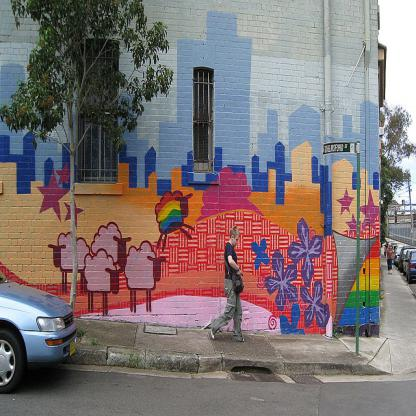

In [33]:
# Check common test and validation folders
possible_folders = [
    ROOT / "dataset_2" / "test" / "images",
    ROOT / "dataset_2" / "valid" / "images",
    ROOT / "dataset_2" / "val" / "images",
]

image_folder = next(
    (folder for folder in possible_folders
     if folder.exists() and any(folder.glob("*"))),
    None
)

if image_folder is None:
    raise FileNotFoundError(
        "Test/validation images folder not found. "
        "Check dataset_2 folder structure."
    )

images = [
    p for p in image_folder.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
]

print("Image folder:", image_folder)
print("Number of images:", len(images))

test_image = random.choice(images)
print("Selected image:", test_image.name)

display(Image.open(test_image).convert("RGB"))


image 1/1 c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_2\test\images\621edf1632f6f63c_jpg.rf.caa3c8e665a2cccfbaf94d9c70999e94.jpg: 640x640 2 Cars, 203.0ms
Speed: 6.7ms preprocess, 203.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\runs\emergency_predictions\test

Detected objects:
Car: 75.04% confidence
Car: 28.61% confidence


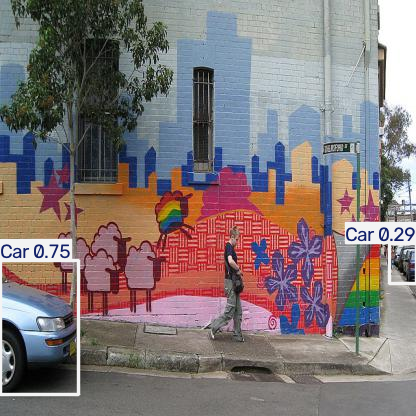

In [34]:
results = model.predict(
    source=str(test_image),
    imgsz=640,
    conf=0.25,
    save=True,
    project=str(ROOT / "runs" / "emergency_predictions"),
    name="test",
    exist_ok=True
)

result = results[0]

print("\nDetected objects:")

if len(result.boxes) == 0:
    print("No objects detected. Try another image.")
else:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        print(
            f"{model.names[class_id]}: "
            f"{confidence * 100:.2f}% confidence"
        )

display(Image.fromarray(result.plot()[..., ::-1]))

In [35]:
from pathlib import Path
from PIL import Image
from IPython.display import display
import yaml

ROOT = Path.cwd().parent

yaml_path = ROOT / "prepared_data" / "dataset_2.yaml"

with open(yaml_path, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

print("Dataset classes:", data["names"])

# Find validation images
candidates = [
    ROOT / "dataset_2" / "valid" / "images",
    ROOT / "dataset_2" / "val" / "images",
    ROOT / "dataset_2" / "test" / "images",
]

image_folder = next(
    (p for p in candidates if p.exists()),
    None
)

if image_folder is None:
    print("Validation/test images folder not found.")
else:
    print("Image folder:", image_folder)
    print("Images available:", len(list(image_folder.iterdir())))

Dataset classes: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']
Image folder: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_2\valid\images
Images available: 250


Ambulance validation images: 50
Selected image: 1f133e6ee29e99d0_jpg.rf.LSDdfZGLMPOupotMQr2C.jpg


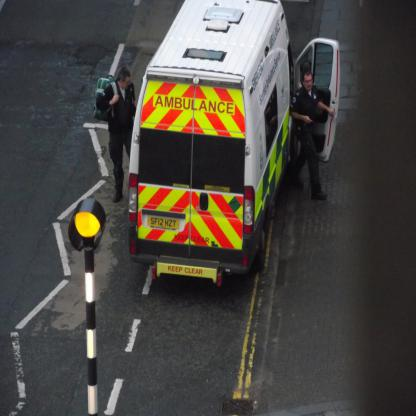

In [36]:
from pathlib import Path
import yaml
import random
from PIL import Image
from IPython.display import display

ROOT = Path.cwd().parent
dataset_path = ROOT / "dataset_2"

with open(ROOT / "prepared_data" / "dataset_2.yaml",
          "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

names = config["names"]

# Find Ambulance class ID
if isinstance(names, dict):
    ambulance_id = next(
        int(k) for k, v in names.items()
        if v.lower() == "ambulance"
    )
else:
    ambulance_id = names.index("Ambulance")

image_dir = dataset_path / "valid" / "images"
label_dir = dataset_path / "valid" / "labels"

ambulance_images = []

for label_file in label_dir.glob("*.txt"):
    lines = label_file.read_text(encoding="utf-8").splitlines()

    if any(
        line.strip() and int(line.split()[0]) == ambulance_id
        for line in lines
    ):
        for ext in [".jpg", ".jpeg", ".png", ".webp"]:
            img_path = image_dir / (label_file.stem + ext)
            if img_path.exists():
                ambulance_images.append(img_path)
                break

print("Ambulance validation images:", len(ambulance_images))

if ambulance_images:
    test_image = random.choice(ambulance_images)
    print("Selected image:", test_image.name)
    display(Image.open(test_image).convert("RGB"))
else:
    print("No ambulance-labelled images found. Check the label folder.")


image 1/1 c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_2\valid\images\1f133e6ee29e99d0_jpg.rf.LSDdfZGLMPOupotMQr2C.jpg: 640x640 1 Truck, 234.4ms
Speed: 10.4ms preprocess, 234.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\runs\emergency_predictions\ambulance_test
Truck: 42.0%


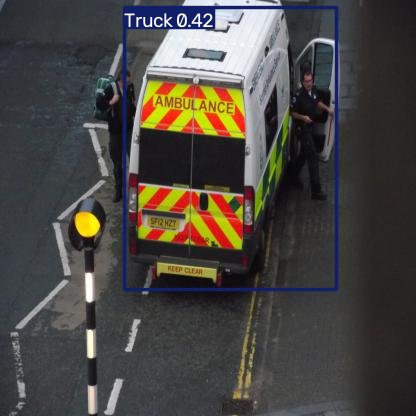

In [37]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image

model_path = (
    ROOT / "runs" / "emergency_vehicle_detection_10epochs"
    / "weights" / "best.pt"
)

model = YOLO(str(model_path))

results = model.predict(
    source=str(test_image),
    imgsz=640,
    conf=0.20,
    save=True,
    project=str(ROOT / "runs" / "emergency_predictions"),
    name="ambulance_test",
    exist_ok=True
)

result = results[0]

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    print(f"{model.names[class_id]}: {confidence:.1%}")

display(Image.fromarray(result.plot()[..., ::-1]))

In [38]:
from pathlib import Path
from ultralytics import YOLO

ROOT = Path.cwd().parent

model_path = (
    ROOT / "runs" / "emergency_vehicle_detection_10epochs"
    / "weights" / "best.pt"
)

yaml_path = ROOT / "prepared_data" / "dataset_2.yaml"

model = YOLO(str(model_path))

metrics = model.val(
    data=str(yaml_path),
    split="val",
    imgsz=640,
    batch=4,
    workers=0,
    plots=True
)

print("Validation completed!")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Per-class mAP50:", metrics.box.maps)
print("Class names:", model.names)

Ultralytics 8.4.173  Python-3.11.17 torch-2.14.1+cpu CPU (13th Gen Intel Core i5-1334U)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.80.2 ms, read: 29.96.3 MB/s, size: 30.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_2\valid\labels.cache... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 2.0it/s 30.9s0.5ss
                   all        250        454      0.716      0.506      0.582      0.435
             Ambulance         50         64      0.886      0.729      0.851      0.719
                   Bus         30         46      0.745      0.652      0.645      0.498
                   Car   

In [39]:
from pathlib import Path
from ultralytics import YOLO

ROOT = Path.cwd().parent

model_path = (
    ROOT / "runs" / "emergency_vehicle_detection_10epochs"
    / "weights" / "best.pt"
)

yaml_path = ROOT / "prepared_data" / "dataset_2.yaml"

model = YOLO(str(model_path))

test_results = model.val(
    data=str(yaml_path),
    split="test",
    imgsz=640,
    batch=4,
    workers=0,
    plots=True,
    project=str(ROOT / "runs"),
    name="emergency_vehicle_test_evaluation",
    exist_ok=True
)

print("\n===== TEST RESULTS =====")
print(f"mAP50:    {test_results.box.map50:.4f}")
print(f"mAP50-95: {test_results.box.map:.4f}")
print("\nPer-class mAP50-95:")

for class_id, score in enumerate(test_results.box.maps):
    print(f"{model.names[class_id]}: {score:.4f}")

Ultralytics 8.4.173  Python-3.11.17 torch-2.14.1+cpu CPU (13th Gen Intel Core i5-1334U)
YOLO11n summary (fused): 100 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.90.1 ms, read: 2.80.7 MB/s, size: 32.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_2\test\labels... 126 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 301.3it/s 0.4s0.0s
val: New cache created: C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_2\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.3it/s 13.8s0.4s
                   all        126        258      0.712      0.632       0.64      0.452
             Ambulance         18         18      0.733          1      0.842      0.772


In [40]:
from pathlib import Path
from ultralytics import YOLO

ROOT = Path.cwd().parent

model_path = (
    ROOT / "runs" / "helmet_detection_10epochs"
    / "weights" / "best.pt"
)

model = YOLO(str(model_path))

print("Model classes:", model.names)

image_path = r"C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\NEW FLODER\runs\detect\predict-3\WhatsApp-Video-2026-03-25-at-15_24_50_mp4-0075_jpg.rf.0c6010a699f1d242f9e834c103ebd39f.jpg"

print("Test image exists:", Path(image_path).exists())

if Path(image_path).exists():
    results = model.predict(
        source=image_path,
        conf=0.10,
        imgsz=640,
        save=False
    )

    result = results[0]

    print("Detections:", len(result.boxes))

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        print(f"{model.names[class_id]}: {confidence:.2%}")

Model classes: {0: 'bike', 1: 'helmet', 2: 'no helmet'}
Test image exists: True

image 1/1 C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\NEW FLODER\runs\detect\predict-3\WhatsApp-Video-2026-03-25-at-15_24_50_mp4-0075_jpg.rf.0c6010a699f1d242f9e834c103ebd39f.jpg: 640x640 2 bikes, 189.6ms
Speed: 5.9ms preprocess, 189.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Detections: 2
bike: 75.69%
bike: 64.73%


In [41]:
image_path = Path(r"C:\path\to\your\original_image.jpg")

In [42]:
image_path = (
    ROOT / "dataset_3" / "valid" / "images"
    / "WhatsApp-Video-2026-03-25-at-15_24_50_mp4-0075_jpg.rf.0c6010a699f1d242f9e834c103ebd39f.jpg"
)


image 1/1 c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_3\valid\images\WhatsApp-Video-2026-03-25-at-15_24_50_mp4-0075_jpg.rf.0c6010a699f1d242f9e834c103ebd39f.jpg: 640x640 2 bikes, 2 helmets, 3 no helmets, 120.6ms
Speed: 6.9ms preprocess, 120.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Classes: {0: 'bike', 1: 'helmet', 2: 'no helmet'}
Objects detected: 7
bike: 94.87%
helmet: 83.90%
bike: 78.07%
no helmet: 37.05%
no helmet: 24.82%
helmet: 13.78%
no helmet: 11.99%


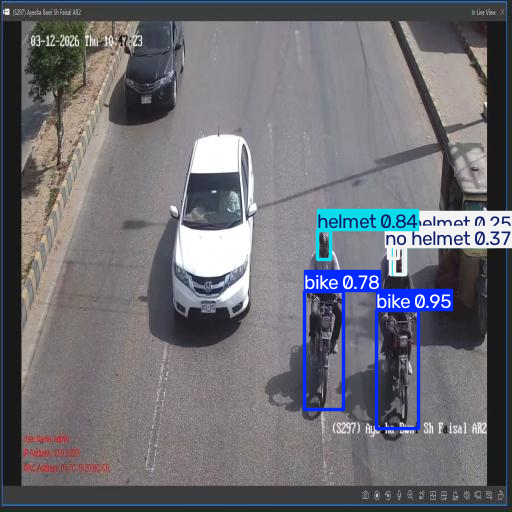

In [43]:

from ultralytics import YOLO
from pathlib import Path
from PIL import Image
from IPython.display import display

ROOT = Path.cwd().parent

model_path = (
    ROOT / "runs" / "helmet_detection_10epochs"
    / "weights" / "best.pt"
)

image_path = (
    ROOT / "dataset_3" / "valid" / "images"
    / "WhatsApp-Video-2026-03-25-at-15_24_50_mp4-0075_jpg.rf.0c6010a699f1d242f9e834c103ebd39f.jpg"
)

if not model_path.exists():
    raise FileNotFoundError(f"Model not found: {model_path}")

if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

model = YOLO(str(model_path))

results = model.predict(
    source=str(image_path),
    imgsz=640,
    conf=0.10,
    save=False
)

result = results[0]

print("Classes:", model.names)
print("Objects detected:", len(result.boxes))

for box in result.boxes:
    class_id = int(box.cls[0])
    score = float(box.conf[0])
    print(f"{model.names[class_id]}: {score:.2%}")

display(Image.fromarray(result.plot()[..., ::-1]))

In [44]:
from ultralytics import YOLO
from pathlib import Path

ROOT = Path.cwd().parent

model_path = (
    ROOT / "runs" / "traffic_detection_finetune_10epochs"
    / "weights" / "best.pt"
)

model = YOLO(str(model_path))
print("Saved model loaded successfully!")

Saved model loaded successfully!
